# Project Pipeline — TSM Next-Day Direction Forecast

End-to-end pipeline for the TSM project. Started in **Stage 04** (data
acquisition) and extended in every later stage: **05** storage, **06**
preprocessing, **07** outliers, **08** EDA, **09** features.

Run the whole notebook top to bottom; each stage re-runs everything built before
it, so the final output is a single reproducible flow.


In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')                    # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))     # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


## Stage 04 — Data Acquisition & Ingestion

Pull TSM daily OHLCV from Yahoo Finance via `yfinance` and save the raw data to
`data/raw/`. Settings (ticker, date range, paths) come from `.env` via
`src.config`.


In [2]:
import pandas as pd
import yfinance as yf

from src.config import TICKER, START, END, DATA_DIR_RAW, DATA_DIR_PROCESSED

print('ticker :', TICKER)
print('range  :', START, '->', END)
print('raw dir:', DATA_DIR_RAW)

ticker : TSM
range  : 2020-01-01 -> 2025-12-31
raw dir: /Users/dorislee/bootcamp_peiyun_lee/project/data/raw


In [3]:
df = yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False)

# yfinance returns MultiIndex columns for a single ticker; keep the Price level
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df.columns.name = None  # drop the leftover "Price" level name

df.index.name = 'Date'
print('shape:', df.shape)
df.head()

shape: (1507, 6)


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,53.503273,60.040001,60.119999,59.599998,59.599998,8432600
2020-01-03,51.738842,58.060001,58.980000,58.040001,58.970001,10546400
2020-01-06,51.141773,57.389999,57.689999,57.130001,57.599998,8897200
2020-01-07,51.970528,58.320000,58.599998,56.740002,57.450001,7444300
2020-01-08,52.353714,58.750000,58.980000,58.110001,58.189999,5381500


In [4]:
DATA_DIR_RAW.mkdir(parents=True, exist_ok=True)
raw_path = DATA_DIR_RAW / f'{TICKER.lower()}.csv'
df.to_csv(raw_path)
print('saved raw data ->', raw_path, '| shape', df.shape)

saved raw data -> /Users/dorislee/bootcamp_peiyun_lee/project/data/raw/tsm.csv | shape (1507, 6)


## Stage 05 — Data Storage

Reload the raw CSV and persist a columnar (Parquet) copy to `data/processed/`,
using the env-driven paths from `src.config` so no path is hard-coded.


In [5]:
raw = pd.read_csv(DATA_DIR_RAW / f'{TICKER.lower()}.csv', index_col='Date', parse_dates=True)
print('reloaded raw:', raw.shape, '| index:', type(raw.index).__name__)

DATA_DIR_PROCESSED.mkdir(parents=True, exist_ok=True)
pq_path = DATA_DIR_PROCESSED / f'{TICKER.lower()}.parquet'
raw.to_parquet(pq_path)
print('saved parquet ->', pq_path)

reloaded raw: (1507, 6) | index: DatetimeIndex
saved parquet -> /Users/dorislee/bootcamp_peiyun_lee/project/data/processed/tsm.parquet


In [6]:
reloaded = pd.read_parquet(pq_path)
checks = {
    'shape_equal': reloaded.shape == raw.shape,
    'index_datetime': isinstance(reloaded.index, pd.DatetimeIndex),
    'columns_equal': list(reloaded.columns) == list(raw.columns),
}
checks

{'shape_equal': True, 'index_datetime': True, 'columns_equal': True}

## Stage 06 — Data Preprocessing

Clean and prepare the data for modeling. Note: the raw TSM series has no missing
values, so `fill_missing_median` / `drop_missing` are no-ops here — they are kept
for robustness because real-world feeds often have gaps.


In [7]:
from src.utils import clean_column_names
from src.cleaning import fill_missing_median, drop_missing, add_features

clean = clean_column_names(raw)                       # 'Adj Close' -> 'adj_close'
clean = drop_missing(clean, threshold=0.5)            # drop >50%-missing columns (no-op here)
clean = fill_missing_median(clean, ['open', 'high', 'low', 'close', 'adj_close', 'volume'])
clean = add_features(clean, close_col='close')        # returns, moving averages, target

print('cleaned shape:', clean.shape)
clean[['close', 'return_1d', 'ma_5', 'ma_20', 'vol_20', 'target']].tail()

cleaned shape: (1507, 11)


,close,return_1d,ma_5,ma_20,vol_20,target
Date,,,,,,
2025-12-23,296.950012,0.012514,288.164001,292.838000,7.827945,1
2025-12-24,298.799988,0.006230,292.532001,293.544000,7.688957,1
2025-12-26,302.839996,0.013521,296.164001,294.188000,7.909211,0
2025-12-29,300.920013,-0.006340,298.558002,294.658501,8.020624,0
2025-12-30,299.579987,-0.004453,299.817999,295.253500,7.916401,0


In [8]:
processed_path = DATA_DIR_PROCESSED / f'{TICKER.lower()}_processed.csv'
clean.to_csv(processed_path)
print('saved processed ->', processed_path, '| shape', clean.shape)

saved processed -> /Users/dorislee/bootcamp_peiyun_lee/project/data/processed/tsm_processed.csv | shape (1507, 11)


## Stage 07 — Outlier Analysis

Flag outliers in the daily returns (IQR and z-score rules) and quantify how the
return distribution changes when outliers are removed vs. winsorized.


In [9]:
from src.outliers import detect_outliers_iqr, detect_outliers_zscore, winsorize_series

ret = clean['return_1d'].dropna()

out_iqr = detect_outliers_iqr(ret)
out_z   = detect_outliers_zscore(ret)
print('IQR outliers    :', int(out_iqr.sum()), f'({out_iqr.mean():.2%})')
print('z-score outliers:', int(out_z.sum()), f'({out_z.mean():.2%})')

# Sensitivity: how do the return stats change under each handling strategy?
wins = winsorize_series(ret)
comparison = pd.DataFrame({
    'all_data': ret.agg(['mean', 'std']),
    'iqr_filtered': ret[~out_iqr].agg(['mean', 'std']),
    'winsorized': wins.agg(['mean', 'std']),
}).round(6)
comparison

IQR outliers    : 52 (3.45%)
z-score outliers: 17 (1.13%)


,all_data,iqr_filtered,winsorized
mean,0.001367,0.000892,0.001180
std,0.024503,0.020166,0.020111


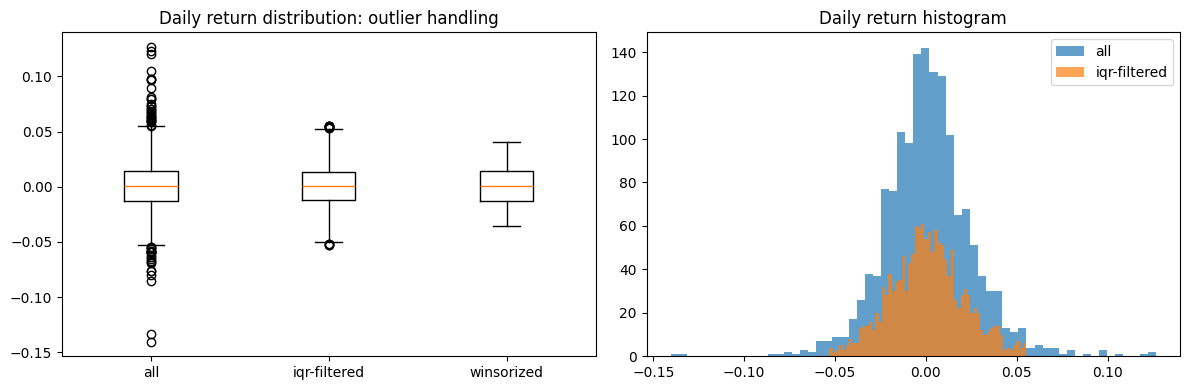

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([ret, ret[~out_iqr], wins])
axes[0].set_xticklabels(['all', 'iqr-filtered', 'winsorized'])
axes[0].set_title('Daily return distribution: outlier handling')
axes[1].hist(ret, bins=60, alpha=0.7, label='all')
axes[1].hist(ret[~out_iqr], bins=60, alpha=0.7, label='iqr-filtered')
axes[1].set_title('Daily return histogram')
axes[1].legend()
plt.tight_layout()
plt.show()

## Stage 08 — Exploratory Data Analysis

Profile the cleaned data with the `eda_summary()` helper (adapted from the
Stage 08 homework) plus a compact flag check. The full visual EDA — time series,
distributions, relationships, correlation matrix — lives in
`notebooks/eda.ipynb`; this cell keeps the pipeline a single reproducible flow.

In [11]:
from src.eda import eda_summary, flag_columns
from IPython.display import display

display(eda_summary(clean))
print('Columns needing attention:', flag_columns(clean))

,dtype,n_missing,pct_missing,n_unique,mean,median,std,min,max,skew,kurtosis
adj_close,float64,0,0.0000,1481,1.215899e+02,1.033139e+02,6.033870e+01,3.948260e+01,3.077153e+02,1.2340,0.9503
close,float64,0,0.0000,1421,1.270210e+02,1.119000e+02,5.932590e+01,4.389000e+01,3.101400e+02,1.1976,0.9166
high,float64,0,0.0000,1411,1.286575e+02,1.134800e+02,6.014700e+01,4.518000e+01,3.139800e+02,1.1959,0.9159
low,float64,0,0.0000,1407,1.253929e+02,1.107500e+02,5.850000e+01,4.270000e+01,3.025000e+02,1.2022,0.9374
open,float64,0,0.0000,1398,1.271069e+02,1.122900e+02,5.942810e+01,4.374000e+01,3.109300e+02,1.2008,0.9366
volume,int64,0,0.0000,1495,1.194012e+07,1.050520e+07,6.409793e+06,2.753900e+06,6.866750e+07,3.0755,16.0246
return_1d,float64,1,0.0007,1505,1.400000e-03,5.000000e-04,2.450000e-02,-1.403000e-01,1.265000e-01,0.2382,3.2488
ma_5,float64,4,0.0027,1491,1.268809e+02,1.124000e+02,5.894440e+01,4.524600e+01,3.030260e+02,1.1933,0.9098
ma_20,float64,19,0.0126,1487,1.263833e+02,1.135792e+02,5.765190e+01,4.752450e+01,2.978865e+02,1.1857,0.9204
vol_20,float64,19,0.0126,1487,4.777600e+00,4.006800e+00,2.840400e+00,7.781000e-01,1.689650e+01,1.1384,1.1649


Columns needing attention: []


## Stage 09 — Feature Engineering

Add momentum, trend-position, volatility, volume-surge and price-range features
via `src/features.py` (the Stage 09 homework functions adapted to OHLCV data).
Rationales are in the `src/features.py` docstrings and the README feature table.

In [12]:
from src.features import build_features

featured = build_features(clean)
new_cols = [c for c in featured.columns if c not in clean.columns]
print('featured shape:', featured.shape)
print('new columns:', new_cols)
featured[new_cols].tail()

# Persist the fully-featured dataset for the modeling stage.
feat_path = DATA_DIR_PROCESSED / f'{TICKER.lower()}_featured.csv'
featured.to_csv(feat_path)
print('saved featured ->', feat_path)

featured shape: (1507, 19)
new columns: ['return_5d', 'return_20d', 'close_to_ma_5', 'close_to_ma_20', 'ma_5_20_spread', 'volume_ratio_20', 'intraday_range', 'overnight_gap']
saved featured -> /Users/dorislee/bootcamp_peiyun_lee/project/data/processed/tsm_featured.csv
